In [1]:
# ============================================================
# 03 - EXPLORATORY ANALYSIS
# HOUSEHOLD PURCHASING POWER IN MOROCCO
# PERIOD: 2007-2024
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ============================================================
# LOAD ANALYTICAL DATASET
# ============================================================

file_path = (
    "../data/processed/"
    "study_02_household_purchasing_power_analytical_2007_2024.xlsx"
)

df = pd.read_excel(file_path)

print("Shape:", df.shape)
print("Period:", df["year"].min(), "-", df["year"].max())

display(df.head())

Shape: (18, 10)
Period: 2007 - 2024


,year,cpi_base_2017_harmonized,disposable_income_s14_harmonized,consumption_s14_harmonized,real_disposable_income,real_consumption,inflation,real_disposable_income_growth,real_consumption_growth,saving_rate
0,2007,86.67,481012,414786,"555,022.60","478,606.78",NaN,NaN,NaN,13.77
1,2008,89.88,529868,462466,"589,540.07","514,547.47",3.71,6.22,7.51,12.72
2,2009,90.81,567820,485171,"625,295.26","534,280.46",1.03,6.06,3.84,14.56
3,2010,91.65,589668,509474,"643,364.49","555,867.84",0.93,2.89,4.04,13.60
4,2011,92.50,621887,539099,"672,315.36","582,814.14",0.92,4.50,4.85,13.31


In [3]:
# ============================================================
# DATA VALIDATION
# ============================================================

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

display(df.describe().T)

Columns:
['year', 'cpi_base_2017_harmonized', 'disposable_income_s14_harmonized', 'consumption_s14_harmonized', 'real_disposable_income', 'real_consumption', 'inflation', 'real_disposable_income_growth', 'real_consumption_growth', 'saving_rate']

Missing values:
year                                0
cpi_base_2017_harmonized            0
disposable_income_s14_harmonized    0
consumption_s14_harmonized          0
real_disposable_income              0
real_consumption                    0
inflation                           1
real_disposable_income_growth       1
real_consumption_growth             1
saving_rate                         0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
year,18.00,"2,015.50",5.34,"2,007.00","2,011.25","2,015.50","2,019.75","2,024.00"
cpi_base_2017_harmonized,18.00,99.42,8.99,86.67,92.80,98.21,102.33,118.70
disposable_income_s14_harmonized,18.00,"740,398.39","159,635.89","481,012.00","627,921.25","731,190.00","816,453.00","1,077,016.00"
consumption_s14_harmonized,18.00,"646,254.50","144,583.41","414,786.00","545,637.50","635,587.50","717,887.75","944,065.00"
real_disposable_income,18.00,"737,265.96","94,799.66","555,022.60","676,632.61","744,593.47","802,505.11","907,342.88"
real_consumption,18.00,"643,073.90","87,161.00","478,606.78","587,952.38","647,182.99","705,625.49","795,336.98"
inflation,17.00,1.88,1.87,0.25,0.92,1.28,1.87,6.64
real_disposable_income_growth,17.00,2.98,3.27,-4.35,0.96,3.32,5.07,8.09
real_consumption_growth,17.00,3.09,3.58,-7.63,2.29,3.22,4.21,10.14
saving_rate,18.00,12.84,1.24,10.54,12.17,12.80,13.60,15.20


In [4]:
# ============================================================
# NOMINAL INDICATORS
# ============================================================

nominal_summary = df[
    [
        "year",
        "disposable_income_s14_harmonized",
        "consumption_s14_harmonized"
    ]
].copy()

nominal_summary.columns = [
    "Year",
    "Disposable Income",
    "Consumption"
]

display(nominal_summary)

,Year,Disposable Income,Consumption
0,2007,481012,414786
1,2008,529868,462466
2,2009,567820,485171
3,2010,589668,509474
4,2011,621887,539099
5,2012,646024,565253
6,2013,686838,593930
7,2014,696519,612719
8,2015,731268,628994
9,2016,731112,642181


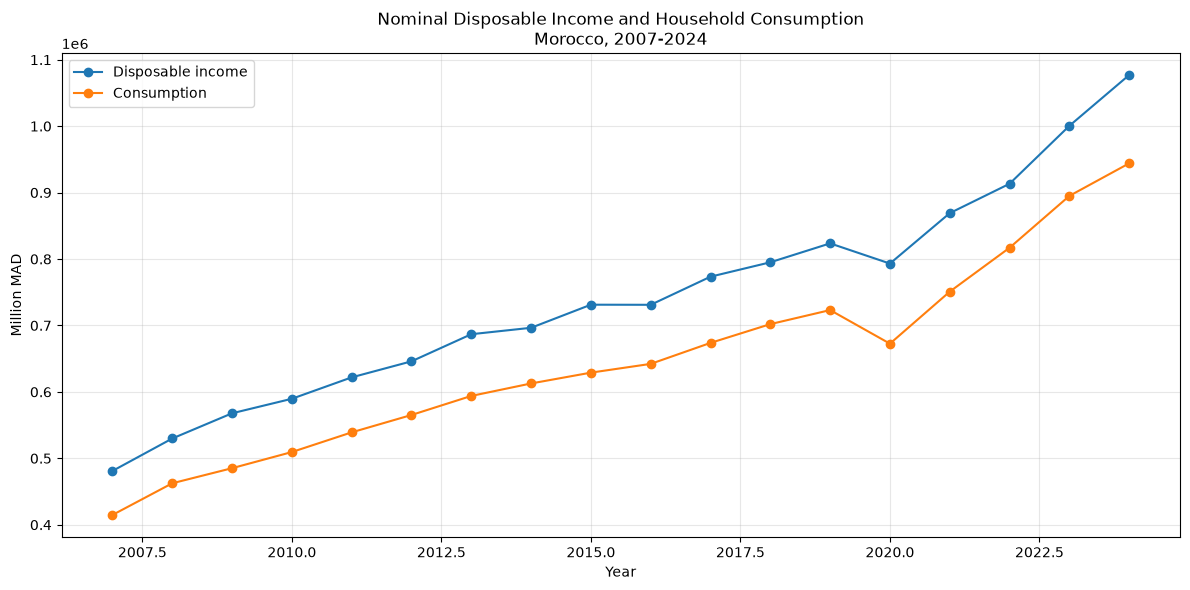

In [5]:
# ============================================================
# FIGURE 01
# NOMINAL DISPOSABLE INCOME AND CONSUMPTION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["disposable_income_s14_harmonized"],
    marker="o",
    label="Disposable income"
)

plt.plot(
    df["year"],
    df["consumption_s14_harmonized"],
    marker="o",
    label="Consumption"
)

plt.title(
    "Nominal Disposable Income and Household Consumption\n"
    "Morocco, 2007-2024"
)

plt.xlabel("Year")
plt.ylabel("Million MAD")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_01_nominal_income_consumption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

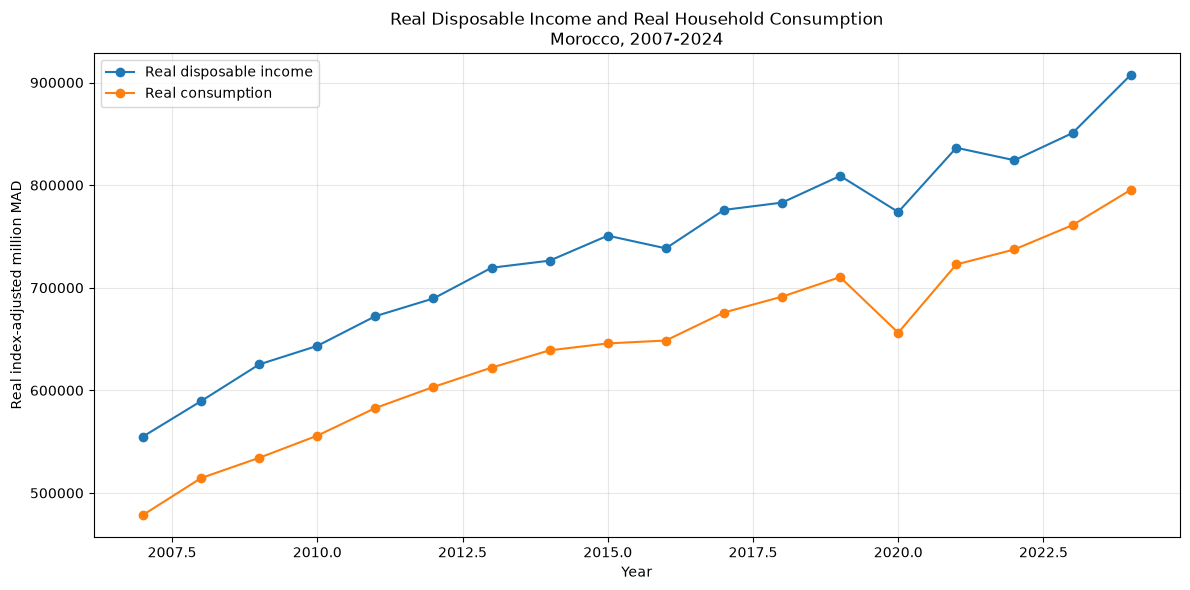

In [6]:
# ============================================================
# FIGURE 02
# REAL DISPOSABLE INCOME AND REAL CONSUMPTION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["real_disposable_income"],
    marker="o",
    label="Real disposable income"
)

plt.plot(
    df["year"],
    df["real_consumption"],
    marker="o",
    label="Real consumption"
)

plt.title(
    "Real Disposable Income and Real Household Consumption\n"
    "Morocco, 2007-2024"
)

plt.xlabel("Year")
plt.ylabel("Real index-adjusted million MAD")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_02_real_income_consumption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

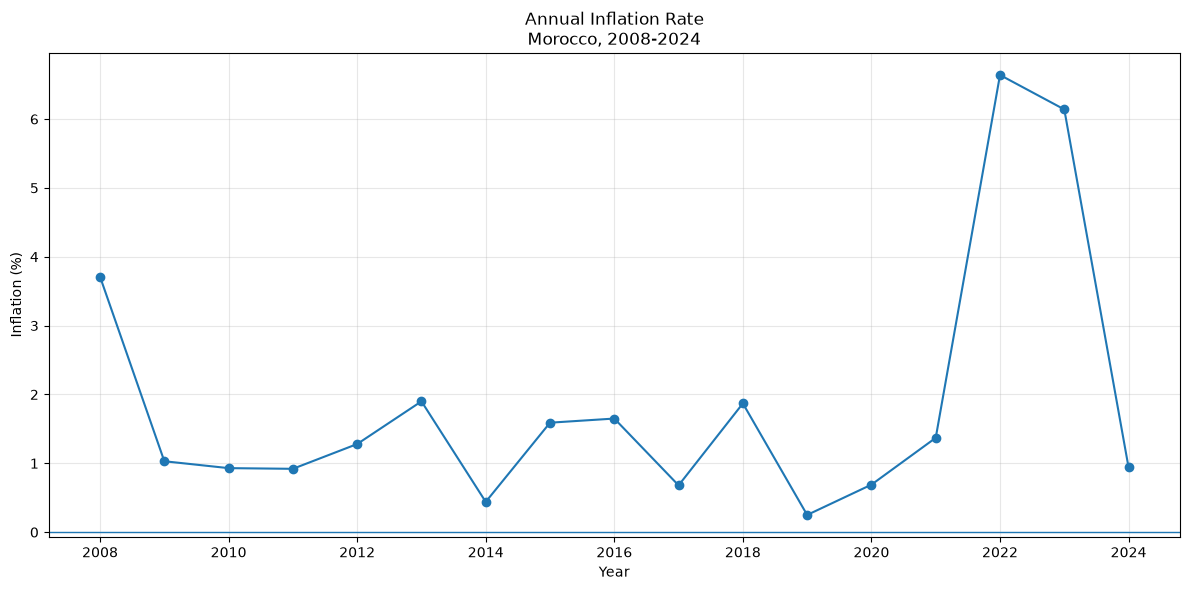

In [7]:
# ============================================================
# FIGURE 03
# ANNUAL INFLATION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["inflation"],
    marker="o"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Annual Inflation Rate\n"
    "Morocco, 2008-2024"
)

plt.xlabel("Year")
plt.ylabel("Inflation (%)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_03_inflation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

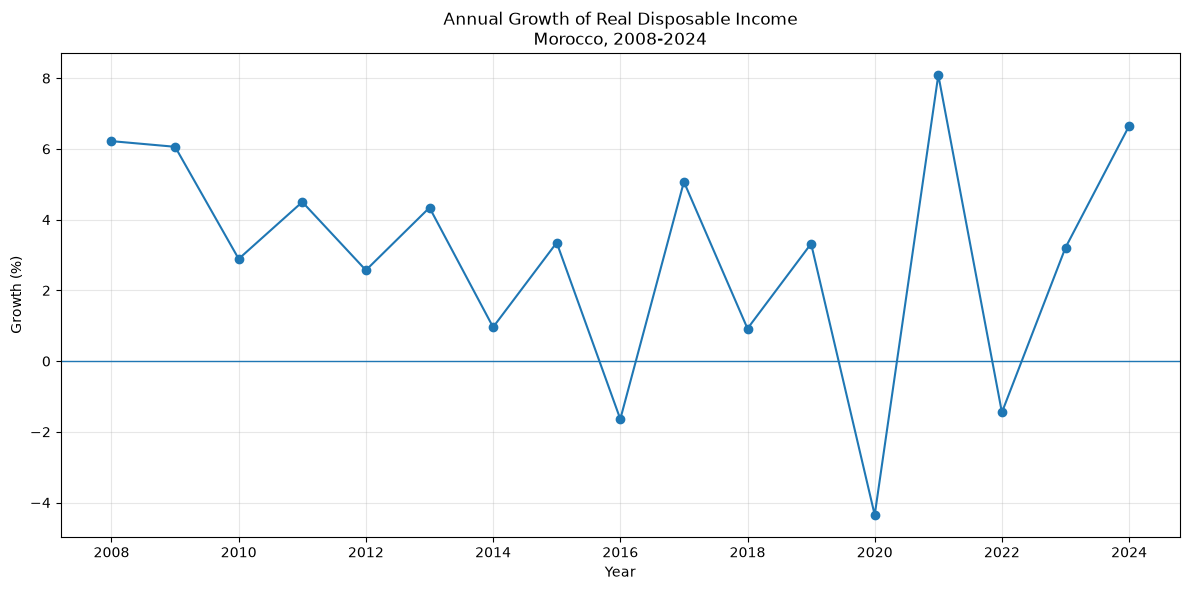

In [8]:
# ============================================================
# FIGURE 04
# REAL DISPOSABLE INCOME GROWTH
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["real_disposable_income_growth"],
    marker="o"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Annual Growth of Real Disposable Income\n"
    "Morocco, 2008-2024"
)

plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_04_real_income_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

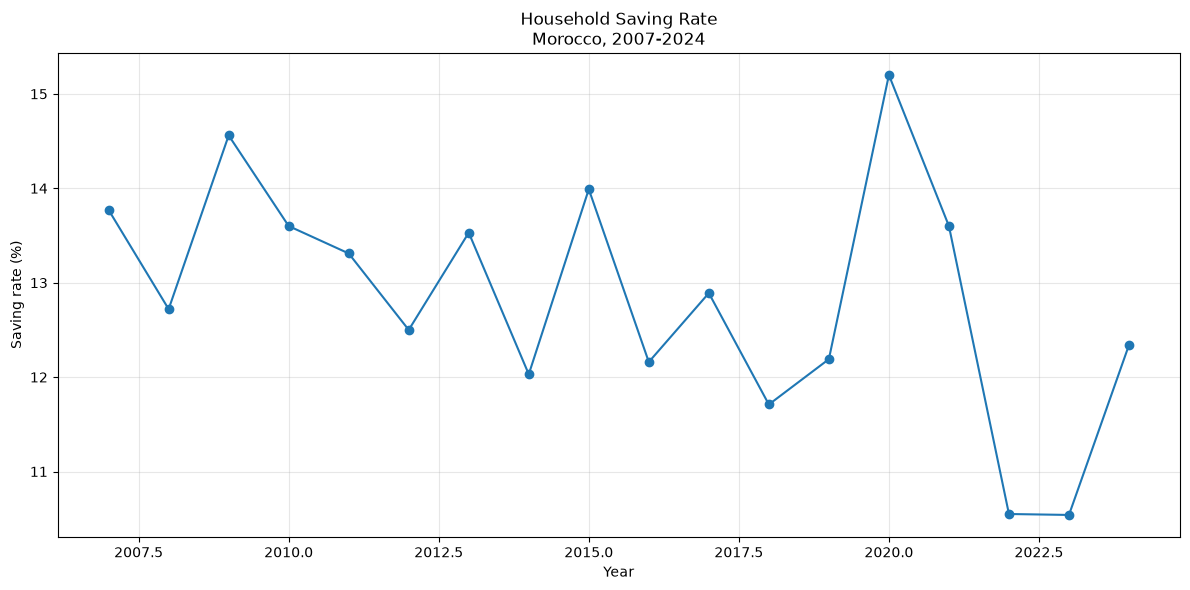

In [9]:
# ============================================================
# FIGURE 05
# HOUSEHOLD SAVING RATE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["saving_rate"],
    marker="o"
)

plt.title(
    "Household Saving Rate\n"
    "Morocco, 2007-2024"
)

plt.xlabel("Year")
plt.ylabel("Saving rate (%)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_05_saving_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ============================================================
# CREATE INDEX BASE 2007 = 100
# ============================================================

df["nominal_income_index_2007"] = (
    df["disposable_income_s14_harmonized"]
    / df["disposable_income_s14_harmonized"].iloc[0]
    * 100
)

df["nominal_consumption_index_2007"] = (
    df["consumption_s14_harmonized"]
    / df["consumption_s14_harmonized"].iloc[0]
    * 100
)

df["real_income_index_2007"] = (
    df["real_disposable_income"]
    / df["real_disposable_income"].iloc[0]
    * 100
)

df["real_consumption_index_2007"] = (
    df["real_consumption"]
    / df["real_consumption"].iloc[0]
    * 100
)

display(
    df[
        [
            "year",
            "nominal_income_index_2007",
            "nominal_consumption_index_2007",
            "real_income_index_2007",
            "real_consumption_index_2007"
        ]
    ]
)

,year,nominal_income_index_2007,nominal_consumption_index_2007,real_income_index_2007,real_consumption_index_2007
0,2007,100.00,100.00,100.00,100.00
1,2008,110.16,111.50,106.22,107.51
2,2009,118.05,116.97,112.66,111.63
3,2010,122.59,122.83,115.92,116.14
4,2011,129.29,129.97,121.13,121.77
5,2012,134.31,136.28,124.24,126.07
6,2013,142.79,143.19,129.64,130.00
7,2014,144.80,147.72,130.88,133.52
8,2015,152.03,151.64,135.27,134.93
9,2016,151.99,154.82,133.04,135.52


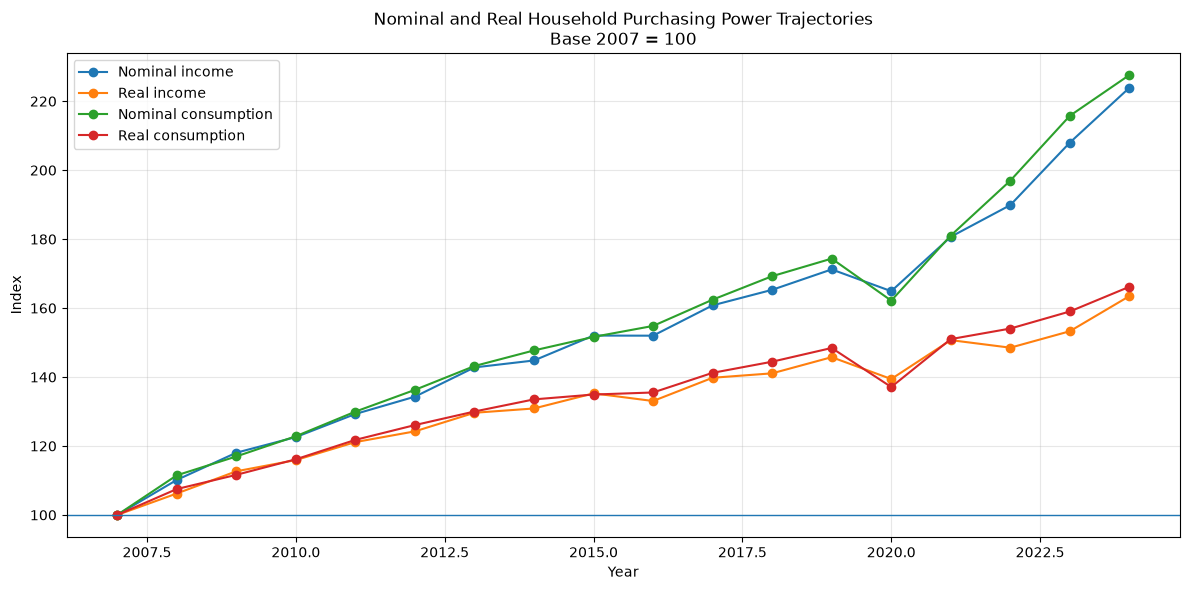

In [11]:
# ============================================================
# FIGURE 06
# NOMINAL VS REAL EVOLUTION
# BASE 2007 = 100
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["year"],
    df["nominal_income_index_2007"],
    marker="o",
    label="Nominal income"
)

plt.plot(
    df["year"],
    df["real_income_index_2007"],
    marker="o",
    label="Real income"
)

plt.plot(
    df["year"],
    df["nominal_consumption_index_2007"],
    marker="o",
    label="Nominal consumption"
)

plt.plot(
    df["year"],
    df["real_consumption_index_2007"],
    marker="o",
    label="Real consumption"
)

plt.axhline(
    y=100,
    linewidth=1
)

plt.title(
    "Nominal and Real Household Purchasing Power Trajectories\n"
    "Base 2007 = 100"
)

plt.xlabel("Year")
plt.ylabel("Index")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure_06_nominal_real_indices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# EXPORT ENRICHED DATASET
# ============================================================

output_path = (
    "../data/processed/"
    "study_02_household_purchasing_power_enriched_2007_2024.xlsx"
)

df.to_excel(output_path, index=False)

print("Enriched dataset exported successfully.")
print(output_path)

Enriched dataset exported successfully.
../data/processed/study_02_household_purchasing_power_enriched_2007_2024.xlsx
